# Reconstructing a chirp across windows, without losing the phase

A compact binary sweeps upward in frequency for far longer than any analysis
window, so its reconstruction is assembled from many windows. Each window is
inverted on its own, and consecutive windows overlap, so every sample in the
overlapped region has two estimates of itself. How those are reconciled decides
whether the assembled waveform still carries the signal's phase.

Phase is the quantity at risk, and it is the one an aggregate does not report. A
reconstruction whose pieces are each correct but each placed slightly wrong
keeps a high overlap while its phase walks; a reconstruction that jumps at one
boundary loses a cycle there and still averages well. The test below is
therefore pointwise: the phase difference against the injected waveform, sample
by sample, with the window boundaries drawn on it.

Nothing here needs a search run. The chirp is generated, cut into windows,
transformed, thresholded as the search thresholds, and reassembled --- which is
the whole path a real trigger's coefficients take.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wdf.analysis.coefficients import from_dense
from wdf.analysis.reconstruction import (
    analytic_signal, phase_residual, stitch, synthesis_weight, waveform_overlap,
)
from wdf.analysis.wavelets import donoho_johnstone_threshold
from wdf.analysis.metaparameters import meta_features
from wdf.mock import waveforms as w
from wdf.structures.array2SeqView import array2SeqView
from pytsa.tsa import WaveletTransform

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.15,
                     "axes.spines.top": False, "axes.spines.right": False})
INK = "#22201d"
C_BLUE, C_ORANGE, C_GREEN = "#276fbf", "#e07b39", "#3f8f5f"

FS = 2048
WINDOW = 512
OVERLAP = 256
STEP = WINDOW - OVERLAP
AMPLITUDE = 8.0

## 1. The signal

A binary black hole inspiral, on the noise scale the triggers are expressed in.
The amplitude is set so that the thresholding below keeps a useful fraction of
the coefficients: the point of the tutorial is what the stitching does to the
phase, not how faint a signal the search can find.

/home/elena/miniconda3/envs/gw-dev/lib/python3.11/importlib/__init__.py:126: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


16.0 s of inspiral, 128 analysis windows at 512 samples stepping 256


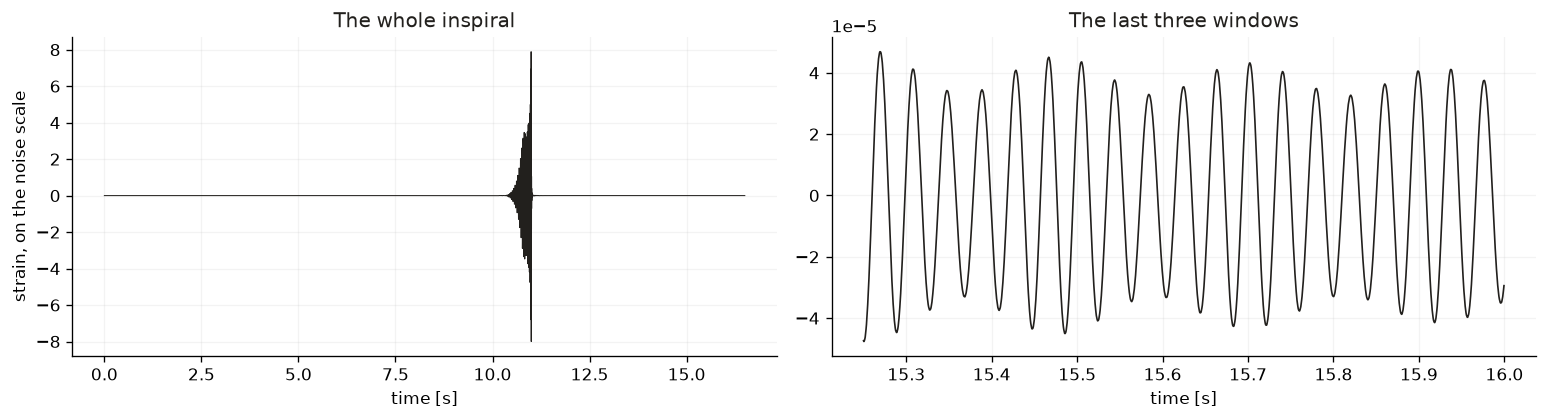

In [2]:
hp, _ = w.cbc_polarisations(mass1=30.0, mass2=30.0, f_lower=30.0,
                            sample_rate=FS)
chirp = np.asarray(hp)
chirp = chirp / np.abs(chirp).max() * AMPLITUDE

n = (len(chirp) // WINDOW + 2) * WINDOW
signal = np.zeros(n)
signal[:len(chirp)] = chirp
time = np.arange(n) / FS

print(f"{len(chirp) / FS:.1f} s of inspiral, "
      f"{len(chirp) // STEP} analysis windows at {WINDOW} samples "
      f"stepping {STEP}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(time, signal, lw=0.6, color=INK)
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("strain, on the noise scale")
axes[0].set_title("The whole inspiral", color=INK)
late = slice(len(chirp) - 3 * WINDOW, len(chirp))
axes[1].plot(time[late], signal[late], lw=1.0, color=INK)
axes[1].set_xlabel("time [s]")
axes[1].set_title("The last three windows", color=INK)
fig.tight_layout()
plt.show()

## 2. What the search keeps

Each window is transformed and thresholded on its own, and a window whose
coefficients all fall below the threshold writes no trigger at all. Two windows
that do trigger and cover the same samples keep different coefficients, and that
is the whole reason the overlapped region has two estimates to reconcile.

The stretch that survives is worth looking at before going on. An inspiral
carries most of its amplitude in its final cycles, and the early part sits far
below the late part rather than slightly below it, so raising the distance scale
moves the boundary of what survives very little. What the reconstruction is
assembled from is therefore the loud end of the signal, spanning several
windows --- which is exactly the case the stitching has to handle.

131 windows analysed, 5 wrote a trigger, 77 coefficients kept in all
the triggers cover 10.50 to 11.25 s of a 16.0 s signal


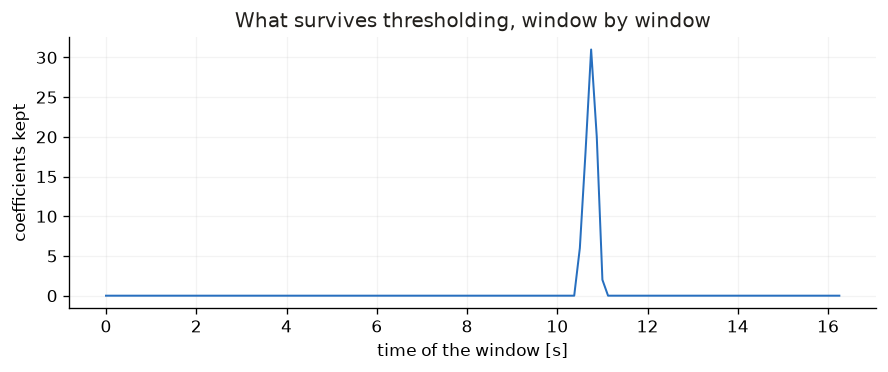

In [3]:
def forward(samples, wave):
    """One window's wavelet coefficients, as the search computes them.

    :param samples: the block to transform.
    :param wave: the basis to transform in.
    :return: numpy.ndarray -- the coefficients, one per sample.
    """
    view = array2SeqView(0.0, 1.0, len(samples))
    view = view.Fill(0.0, np.asarray(samples, dtype=float).copy())
    WaveletTransform(len(samples), getattr(WaveletTransform, wave)).Forward(view)
    return np.array([view.GetY(0, i) for i in range(len(samples))])


def as_the_search_writes_it(signal, fs, window, overlap, gps0=0.0,
                            wave="DaubC12", sigma=1.0):
    """One trigger per window, carrying the coefficients that passed threshold.

    This is the whole front end in one function: cut the strain into blocks,
    transform each, keep what stands above the noise, and record the survivors
    with the time of the block they came from.

    :param signal: the samples the windows are cut from.
    :param fs: sampling frequency, Hz.
    :param window: analysis window length, samples.
    :param overlap: overlap between consecutive windows, samples.
    :param gps0: time of the first sample.
    :param wave: the basis to transform in.
    :param sigma: noise scale the threshold and the amplitudes are expressed on.
    :return: pandas.DataFrame -- the triggers, thresholded.
    """
    cut = donoho_johnstone_threshold(sigma, window)
    step = window - overlap
    rows = []
    for first in range(0, len(signal) - window + 1, step):
        coefficients = forward(signal[first:first + window], wave)
        index, value = from_dense(np.where(np.abs(coefficients) > cut,
                                           coefficients, 0.0))
        gps = gps0 + first / fs
        rows.append(dict(
            meta_features(index, value, window, fs, sigma, gps=gps),
            gps=gps, EnWDF=float(np.linalg.norm(value) / sigma), sigma=sigma,
            wave=wave, n_coeff=window, fs=fs,
            wt_index=index, wt_value=value, ifo="H1"))
    return pd.DataFrame(rows)


ANALYSED = as_the_search_writes_it(signal, FS, WINDOW, OVERLAP)
survivors = ANALYSED.wt_index.map(len)
TRIGGERS = ANALYSED[survivors > 0].reset_index(drop=True)

print(f"{len(ANALYSED)} windows analysed, {len(TRIGGERS)} wrote a trigger, "
      f"{survivors.sum()} coefficients kept in all")
print(f"the triggers cover {TRIGGERS.gps.min():.2f} to "
      f"{TRIGGERS.gps.max() + WINDOW / FS:.2f} s of a "
      f"{len(chirp) / FS:.1f} s signal")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(ANALYSED.gps, survivors, lw=1.2, color=C_BLUE)
ax.set_xlabel("time of the window [s]")
ax.set_ylabel("coefficients kept")
ax.set_title("What survives thresholding, window by window", color=INK)
fig.tight_layout()
plt.show()

## 3. The weight that joins two windows

The search applies no window function --- it transforms the block as it is ---
so there is no analysis taper the synthesis has to be the counterpart of. The
weight is introduced by the stitching, and what it has to satisfy is that it
vanish at the block edges: a weight that does not leaves a step wherever the two
estimates disagree.

The two ramps are complementary, so wherever a sample is covered by both
windows they sum to one. The reconstruction in the overlapped region is
therefore a weighted average of the two estimates and not a rescaling of
either.

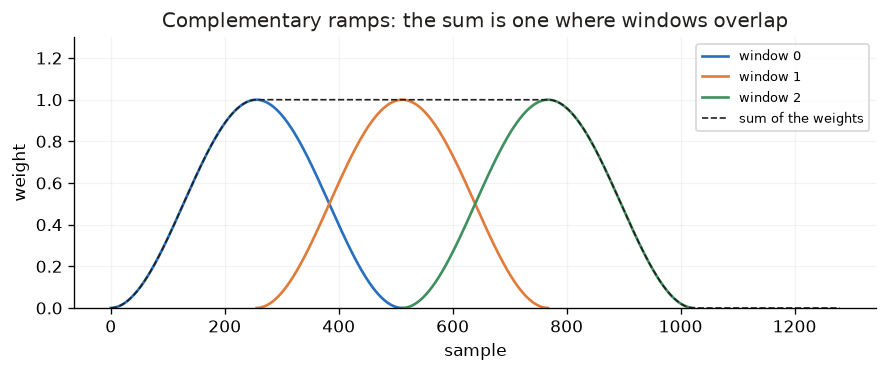

In [4]:
weight = synthesis_weight(WINDOW, OVERLAP)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for k in range(3):
    ax.plot(k * STEP + np.arange(WINDOW), weight, lw=1.6,
            color=[C_BLUE, C_ORANGE, C_GREEN][k], label=f"window {k}")
covered = np.zeros(3 * STEP + WINDOW)
for k in range(3):
    covered[k * STEP:k * STEP + WINDOW] += weight
ax.plot(covered, lw=1.0, ls="--", color=INK, label="sum of the weights")
ax.set_xlabel("sample")
ax.set_ylabel("weight")
ax.set_ylim(0, 1.3)
ax.set_title("Complementary ramps: the sum is one where windows overlap",
             color=INK)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Three ways to join the pieces

`central_window` gives each window the samples of its own step: the pieces tile
the span once, and every boundary is a switch from one estimate to another.
`overlap_add` averages the two with the weight above. `taper_edges` additionally
ramps the series where coverage begins and ends, where there is only one
estimate and nothing to average with.

Three quantities are read for each. The overlap is the normalized inner product
against the injected waveform, which is phase sensitive: a reconstruction with
the right envelope and the wrong phase cancels term by term. The lag is the
shift that would maximize it, and must be zero if the reconstruction sits where
the signal is. The phase residual is the pointwise difference of the two
unwrapped phases --- the quantity the other two can hide.

In [5]:
RECONSTRUCTIONS = {}
rows = []
for label, policy, taper in (("central_window", "central_window", False),
                             ("overlap_add", "overlap_add", False),
                             ("overlap_add + taper_edges", "overlap_add", True)):
    start, samples = stitch(TRIGGERS, float(FS), WINDOW, OVERLAP,
                            overlap_policy=policy, taper_edges=taper)
    # The comparison runs on the samples the reconstruction actually covers.
    # Padding it back out to the whole signal would score the silence as
    # agreement and read as a better recovery than was made.
    first = int(round(start * FS))
    reference = signal[first:first + len(samples)]
    agreement = waveform_overlap(samples, reference, max_lag=4)
    phase = phase_residual(samples, reference)
    RECONSTRUCTIONS[label] = (samples, reference, phase)
    rows.append(dict(stitching=label, overlap=agreement["overlap"],
                     lag_samples=agreement["lag"],
                     overlap_at_zero_lag=agreement["overlap_at_zero_lag"],
                     phase_median_rad=phase["median_abs"],
                     phase_max_rad=float(np.abs(phase["residual"]).max())))

print(pd.DataFrame(rows).to_string(index=False,
                                   float_format=lambda v: f"{v:.4f}"))

                stitching  overlap  lag_samples  overlap_at_zero_lag  phase_median_rad  phase_max_rad
           central_window   0.9776            0               0.9776            0.0821         5.2144
              overlap_add   0.9855            0               0.9855            0.0605         1.3361
overlap_add + taper_edges   0.9867            0               0.9867            0.0582         1.3304


## 5. The phase, sample by sample

The residual is drawn against time with the window boundaries marked. What to
look for is not its size but its shape: a flat residual means the phase is
carried through; a staircase means it is being lost at the boundaries; a slope
means the reconstruction is drifting against the signal.

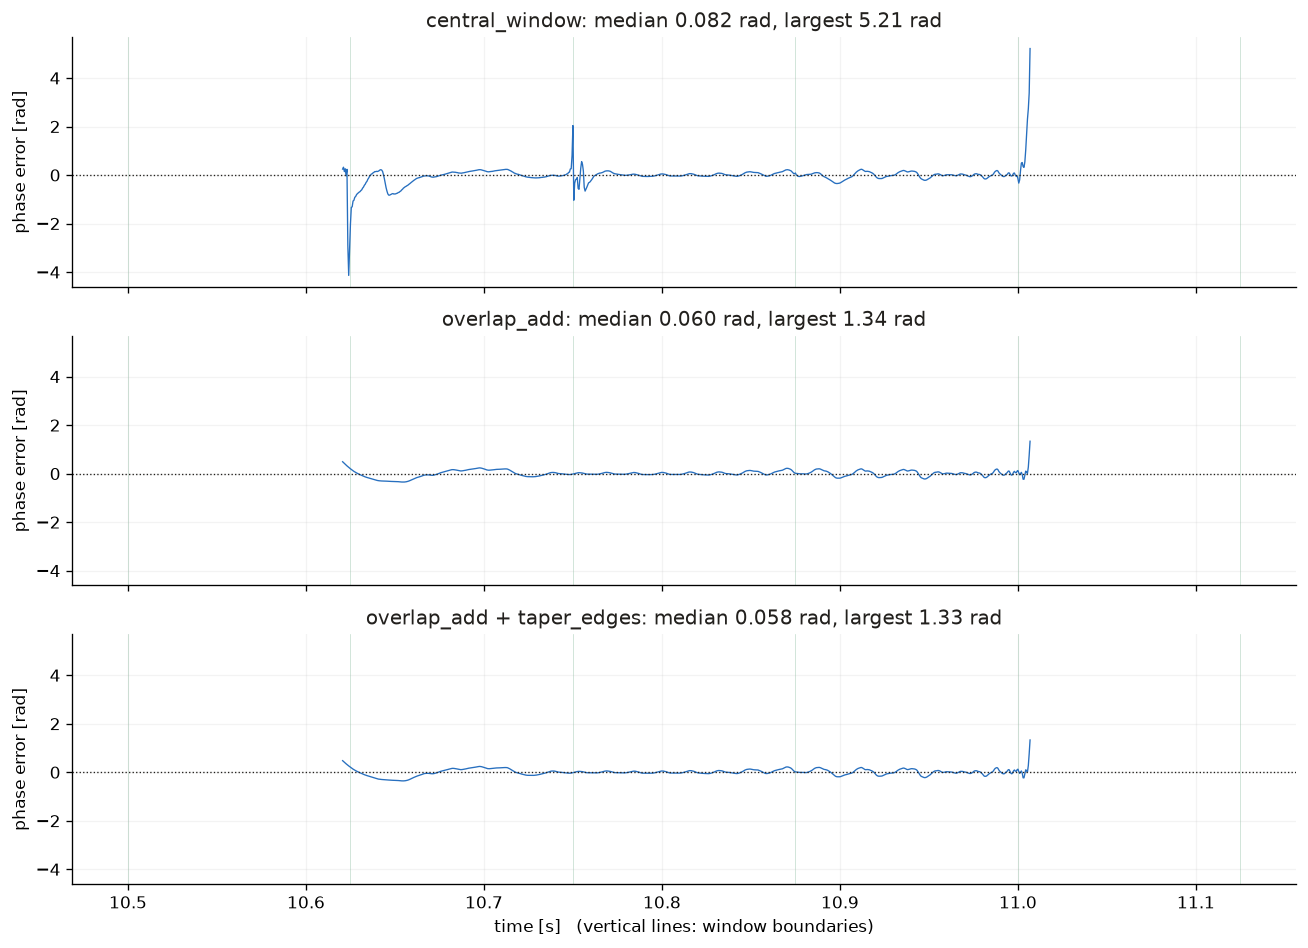

In [6]:
START = int(round(stitch(TRIGGERS, float(FS), WINDOW, OVERLAP)[0] * FS))

fig, axes = plt.subplots(len(RECONSTRUCTIONS), 1, figsize=(11, 8),
                         sharex=True, sharey=True)
for ax, (label, (samples, reference, phase)) in zip(axes, RECONSTRUCTIONS.items()):
    where = phase["where"]
    ax.plot((START + where) / FS, phase["residual"], lw=0.8, color=C_BLUE)
    for boundary in range(0, len(samples), STEP):
        ax.axvline((START + boundary) / FS, color=C_GREEN, lw=0.4, alpha=0.35,
                   zorder=0)
    ax.axhline(0.0, color=INK, lw=0.8, ls=":")
    ax.set_ylabel("phase error [rad]")
    ax.set_title(f"{label}: median {phase['median_abs']:.3f} rad, "
                 f"largest {np.abs(phase['residual']).max():.2f} rad", color=INK)
axes[-1].set_xlabel("time [s]   (vertical lines: window boundaries)")
fig.tight_layout()
plt.show()

## 6. Where the phase error actually is

A single largest residual says little without knowing where it sits. Binned by
the injected envelope, the residual separates the samples where there is a
signal to carry a phase from the samples at the edge of the mask, where
thresholding has removed most of what was there and what is left is a fragment
whose phase is barely defined.

Phase error against the amplitude of the signal carrying it:
  envelope  samples  median_rad  largest_rad
0.1 to 0.3      267      0.1428       1.3361
0.3 to 0.6      469      0.0404       0.2315
0.6 to 1.0       56      0.0551       0.1916


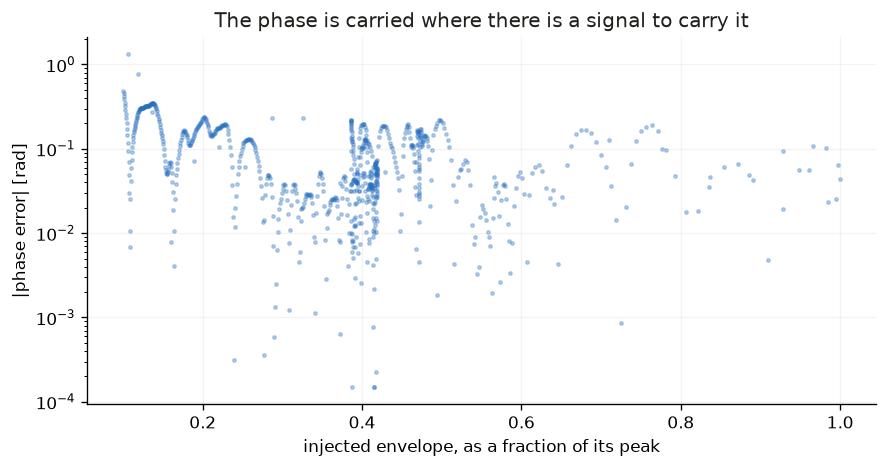

In [7]:
samples, reference, phase = RECONSTRUCTIONS["overlap_add"]
envelope = np.abs(analytic_signal(reference))[phase["where"]]
envelope = envelope / envelope.max()

bands = [(0.1, 0.3), (0.3, 0.6), (0.6, 1.01)]
rows = []
for low, high in bands:
    inside = (envelope >= low) & (envelope < high)
    if not inside.any():
        continue
    residual = np.abs(phase["residual"][inside])
    rows.append(dict(envelope=f"{low:.1f} to {high:.1f}", samples=int(inside.sum()),
                     median_rad=float(np.median(residual)),
                     largest_rad=float(residual.max())))
print("Phase error against the amplitude of the signal carrying it:")
print(pd.DataFrame(rows).to_string(index=False,
                                   float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.scatter(envelope, np.abs(phase["residual"]), s=4, alpha=0.3, color=C_BLUE)
ax.set_yscale("log")
ax.set_xlabel("injected envelope, as a fraction of its peak")
ax.set_ylabel("|phase error| [rad]")
ax.set_title("The phase is carried where there is a signal to carry it", color=INK)
fig.tight_layout()
plt.show()

## 7. More shifts, or a better weight?

Thresholding a decimated wavelet transform is known to leave pseudo-Gibbs
oscillations near a discontinuity, because the basis is not translation
invariant, and the documented remedy is to average the estimate over shifts of
the data --- cycle spinning. Overlapping windows already do exactly that: a
sample covered by `window / step` windows is an average over that many shifts,
so the overlap is the number of shifts and can simply be raised.

Whether that helps here is a question about which artefact dominates. Averaging
over shifts removes what depends on where the grid falls; it cannot restore a
coefficient that was below threshold in every shifted copy alike.

In [8]:
rows = []
for overlap in (256, 384, 448, 480):
    triggers = as_the_search_writes_it(signal, FS, WINDOW, overlap)
    triggers = triggers[triggers.wt_index.map(len) > 0].reset_index(drop=True)
    for policy in ("central_window", "overlap_add"):
        start, samples = stitch(triggers, float(FS), WINDOW, overlap,
                                overlap_policy=policy)
        first = int(round(start * FS))
        reference = signal[first:first + len(samples)]
        agreement = waveform_overlap(samples, reference, max_lag=4)
        phase = phase_residual(samples, reference)
        rows.append(dict(overlap=overlap, shifts=WINDOW // (WINDOW - overlap),
                         triggers=len(triggers), stitching=policy,
                         overlap_with_injection=agreement["overlap"],
                         lag_samples=agreement["lag"],
                         phase_median_rad=phase["median_abs"],
                         phase_max_rad=float(np.abs(phase["residual"]).max())))

print("Averaging over more shifts of the analysis grid:")
print(pd.DataFrame(rows).to_string(index=False,
                                   float_format=lambda v: f"{v:.4f}"))

Averaging over more shifts of the analysis grid:
 overlap  shifts  triggers      stitching  overlap_with_injection  lag_samples  phase_median_rad  phase_max_rad
     256       2         5 central_window                  0.9776            0            0.0821         5.2144
     256       2         5    overlap_add                  0.9855            0            0.0605         1.3361
     384       4        10 central_window                  0.9696            0            0.0792         5.6536
     384       4        10    overlap_add                  0.9852            0            0.0619         1.3552
     448       8        20 central_window                  0.9576            0            0.1079         4.8592
     448       8        20    overlap_add                  0.9863            0            0.0576         1.3317
     480      16        39 central_window                  0.9320            0            0.1414         4.2034
     480      16        39    overlap_add              

## 8. A boundary, up close

The same comparison in the time domain, on the samples around one window
boundary late in the inspiral, where the frequency is highest and a
misplacement costs the most phase.

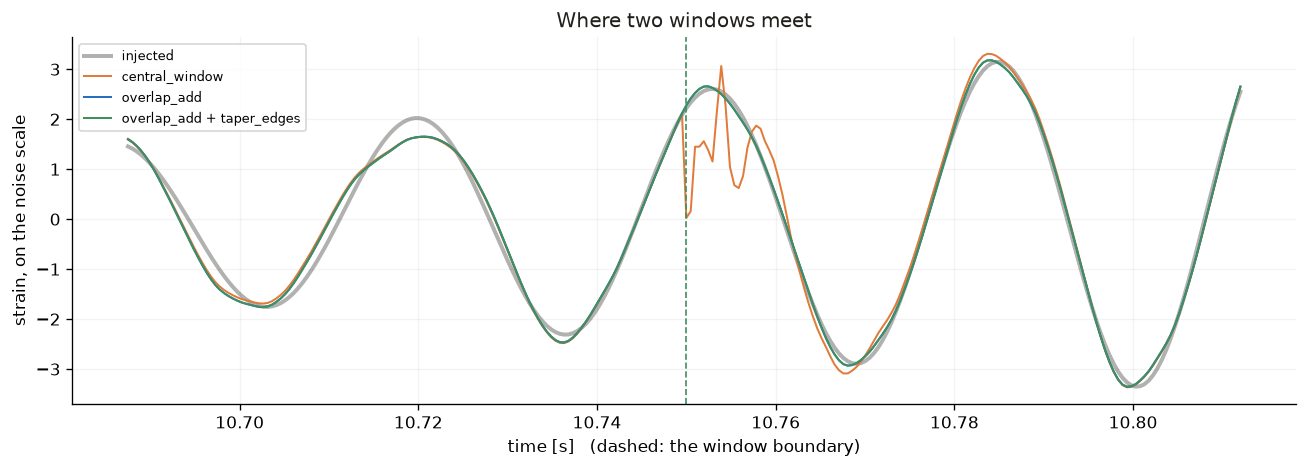

In [9]:
edge = (len(TRIGGERS) // 2) * STEP
around = slice(max(edge - STEP // 2, 0), edge + STEP // 2)
axis = (START + np.arange(len(RECONSTRUCTIONS["overlap_add"][0]))) / FS

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(axis[around], RECONSTRUCTIONS["overlap_add"][1][around], lw=2.4,
        color=INK, alpha=0.35, label="injected")
for label, colour in zip(RECONSTRUCTIONS, (C_ORANGE, C_BLUE, C_GREEN)):
    ax.plot(axis[around], RECONSTRUCTIONS[label][0][around], lw=1.2,
            color=colour, label=label)
ax.axvline((START + edge) / FS, color=C_GREEN, lw=1.0, ls="--")
ax.set_xlabel("time [s]   (dashed: the window boundary)")
ax.set_ylabel("strain, on the noise scale")
ax.set_title("Where two windows meet", color=INK)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## What this shows, and what it does not

The reconstruction is assembled from coefficients alone: the injected waveform
enters only as the thing the result is compared against, never as something the
stitching is told. A lag of zero says the assembled waveform sits where the
signal is, to the sample, and the phase error read where the signal is loud says
it carries the signal's phase and not merely its envelope.

What the comparison cannot say is anything about the part of the signal the
search did not keep. The residual is masked to the samples whose envelope
reaches a fraction of the peak, and it grows towards the edge of that mask,
where thresholding has removed most of what was there. That is a statement about
which coefficients survive, not about how the surviving ones are joined --- and
it is why averaging over more shifts of the analysis grid changes the boundaries
without changing the phase: a coefficient below threshold is below it in every
shifted copy alike.